In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=2, fmin=0.5, fmax=16)
dataset = BNCI2014008()

In [3]:
subject, session, run = 2, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-0.188 – 1.969 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


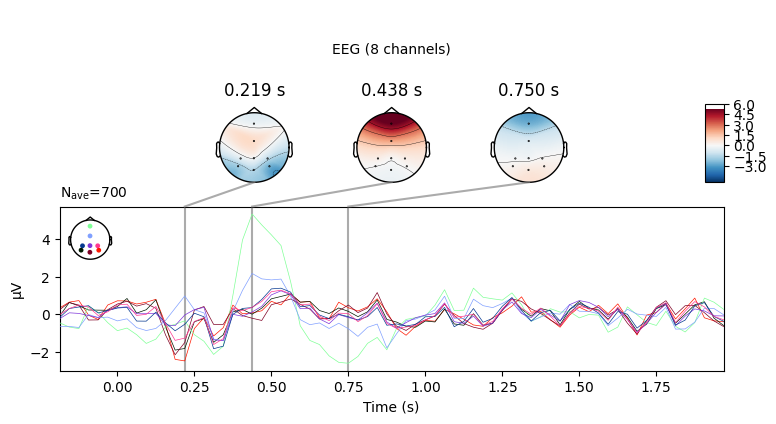

No projector specified for this dataset. Please consider the method self.add_proj.


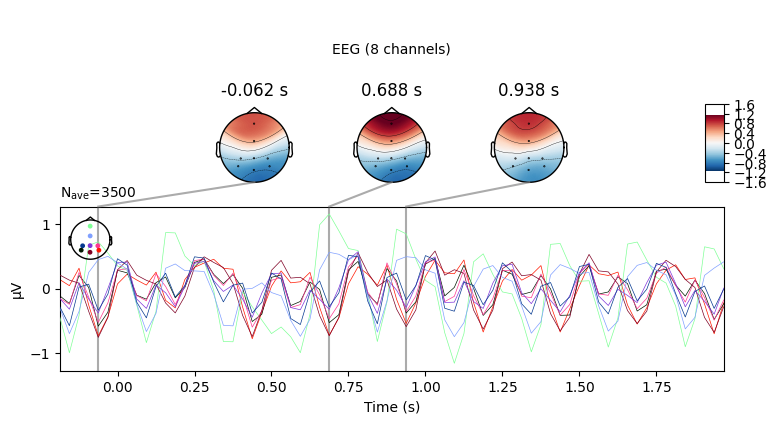

No projector specified for this dataset. Please consider the method self.add_proj.


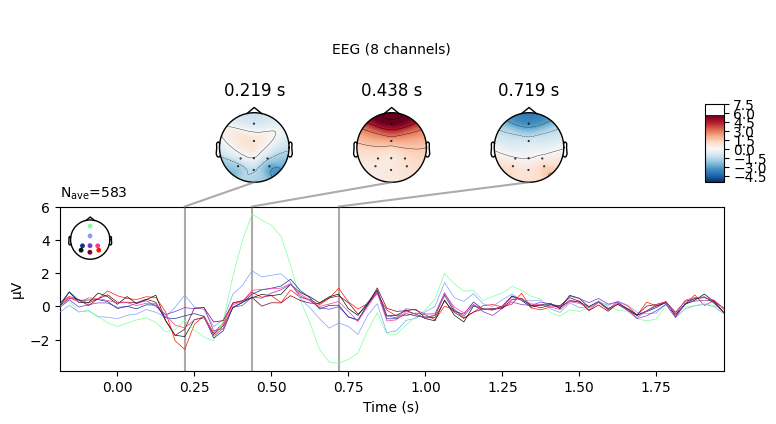

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

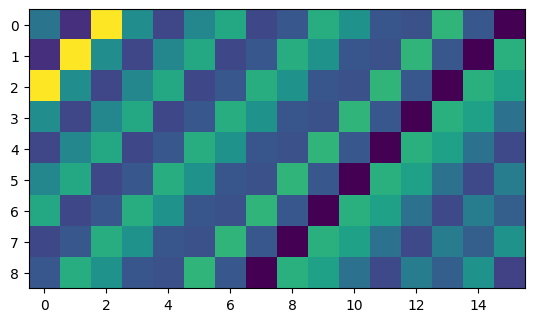

In [6]:
roi0 = int((0 - epochs.tmin)*epochs.info['sfreq'])
roi1 = int((0.3 - epochs.tmin)*epochs.info['sfreq'])
n_times = roi1-roi0
n_epochs = len(epochs)
n_channels = len(epochs.ch_names)
n_lags= 16
X = np.zeros((n_epochs, n_channels, n_times, n_lags))

for l in range(n_lags):
    X[:,:,:,l] = epochs.get_data()[:,:,roi0+l:roi1+l]
X = X.astype(np.float32)


In [8]:
X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [9]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [10]:
tl.SVD_FUNS

{'numpy_svd': <bound method Backend.partial_svd of TensorLy jax-backend>,
 'truncated_svd': <bound method Backend.truncated_svd of TensorLy jax-backend>,
 'symeig_svd': <bound method Backend.symeig_svd of TensorLy jax-backend>,
 'randomized_svd': <bound method Backend.randomized_svd of TensorLy jax-backend>}

In [11]:
hoda = HODA(max_iter=128, rank=(2,2,2), tol=0,
            initialize ='identity', verbose=True,
            shrinkage=(0.2,0.2, 0.2))
# %lprun -f tl_toeplitz hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=2.2458e+00
[1/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.9244e+00
[2/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.6992e+00
[3/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.3285e+00
[4/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=6.6234e-01
[5/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=8.4257e-01
[6/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.0610e+00
[7/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.3761e+00
[8/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.5747e+00
[9/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.6168e+00
[10/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.5627e+00
[11/128]  shrinkage[0]=0.2000  

[92/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[93/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[94/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[95/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[96/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[97/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[98/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[99/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[100/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[101/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[102/128]  shrinkage[0]=0.2000  shrinkage[1]=0.2000  shrinkage[2]=0.2000  step=1.7717e+00
[103/128]  shrinka

HODA(max_iter=128, rank=(2, 2, 2), shrinkage=(0.2, 0.2, 0.2), tol=0,
     verbose=True)

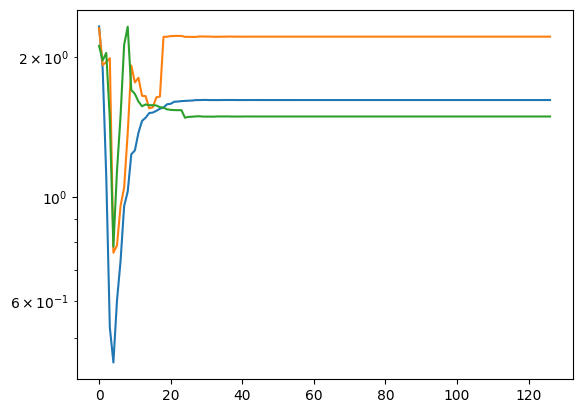

In [12]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

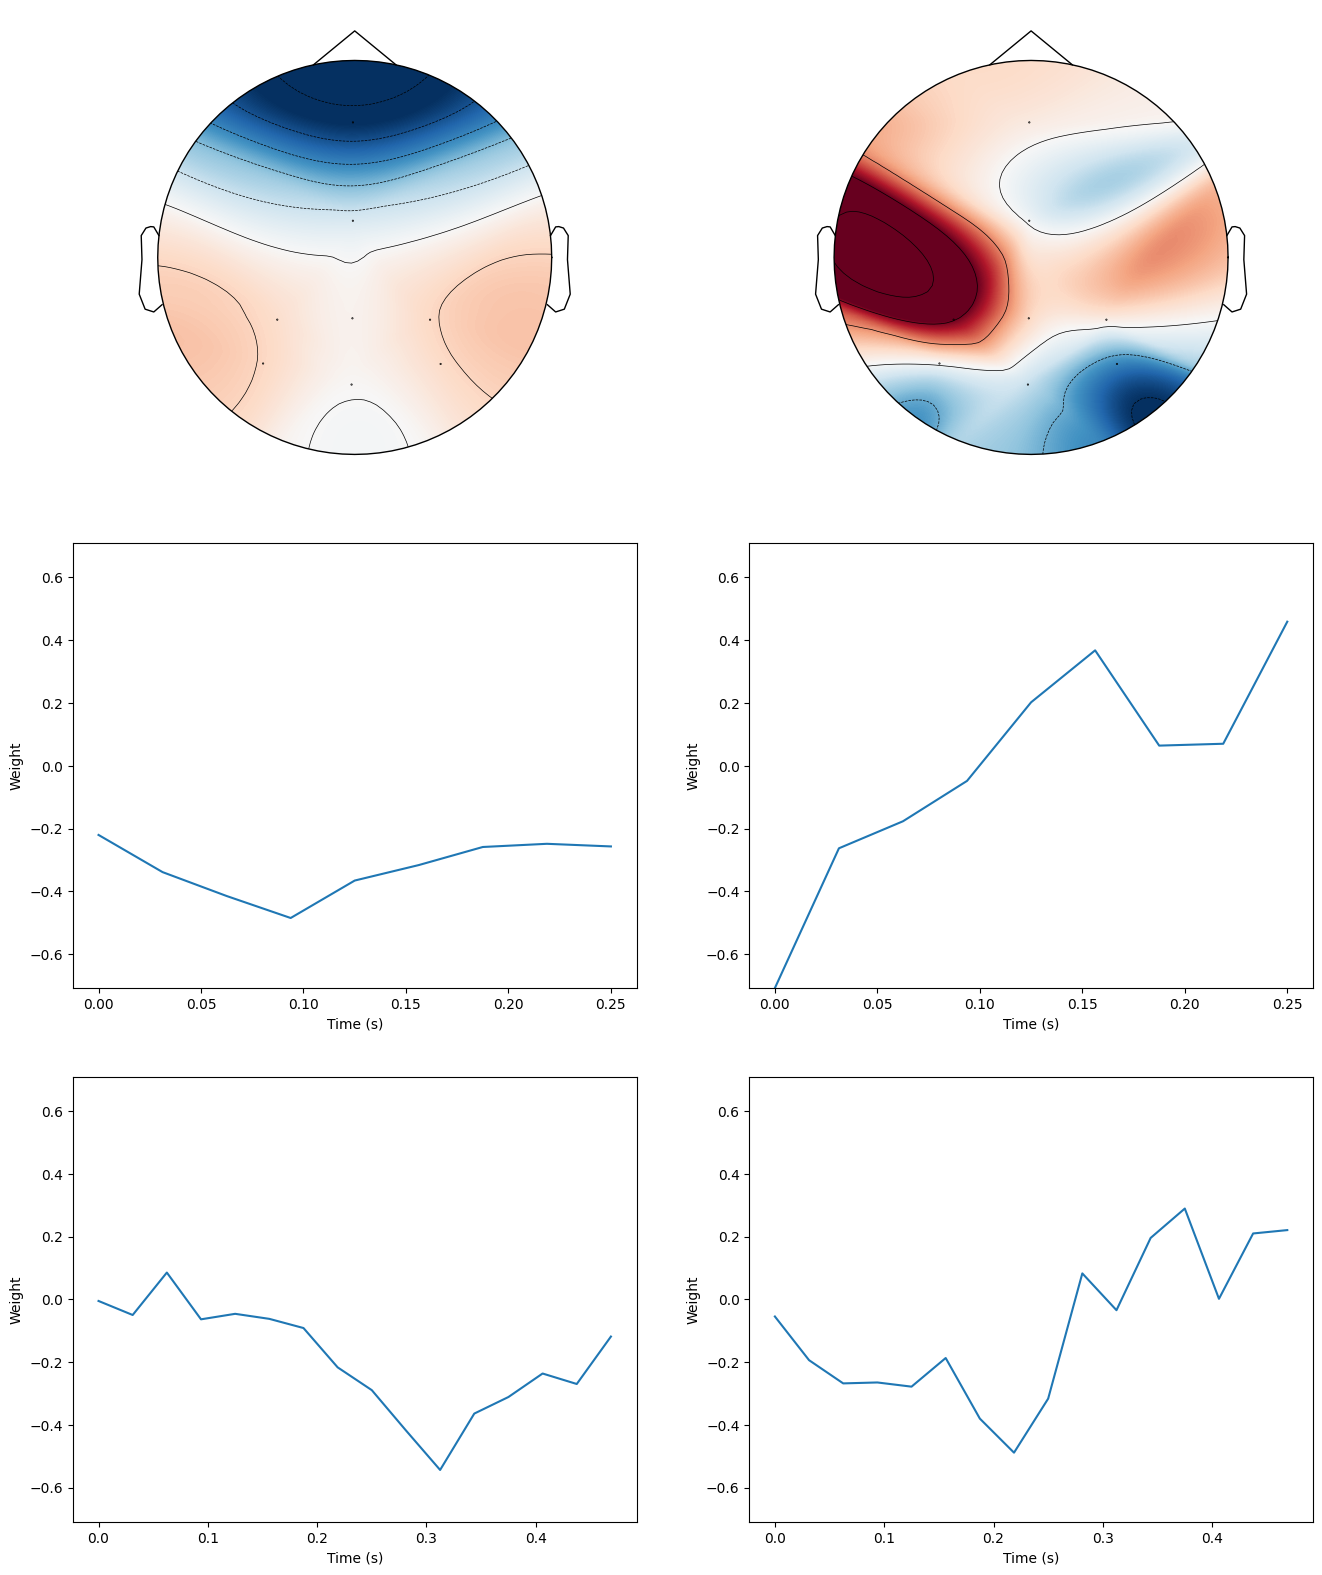

In [16]:

fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
projs = [p for p in hoda.projs_]
for i in range(hoda.rank[0]):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank[1]):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
for i in range(hoda.rank[2]):
    w = projs[2][:,i]
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])


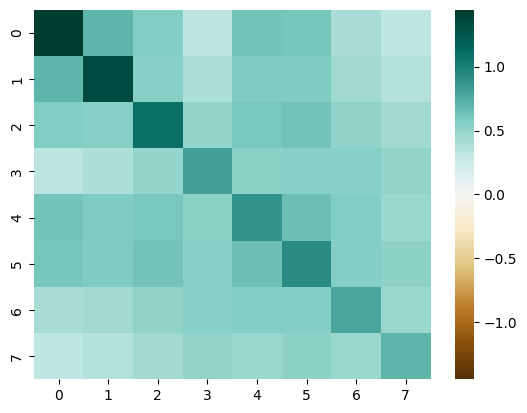

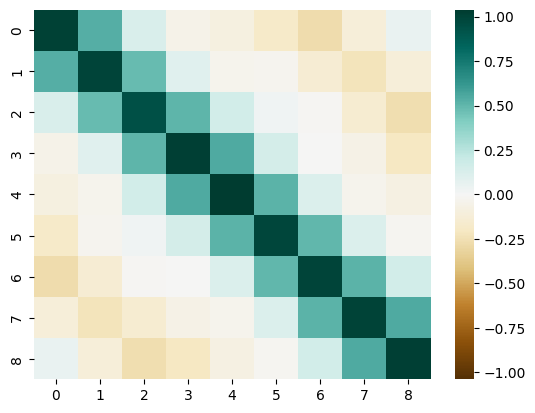

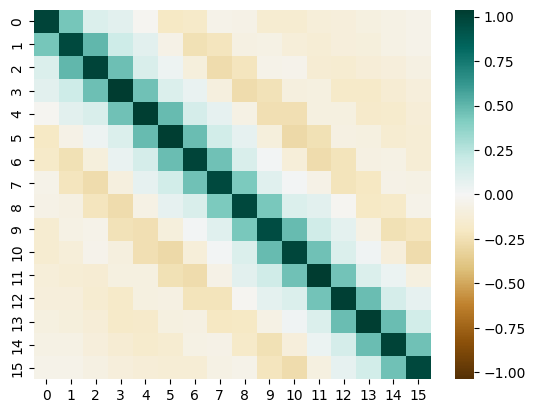

In [17]:
for k in range(3):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

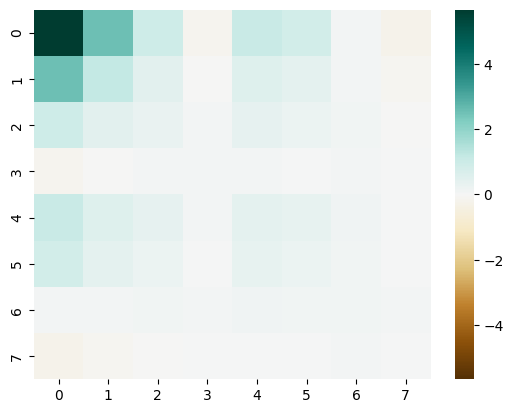

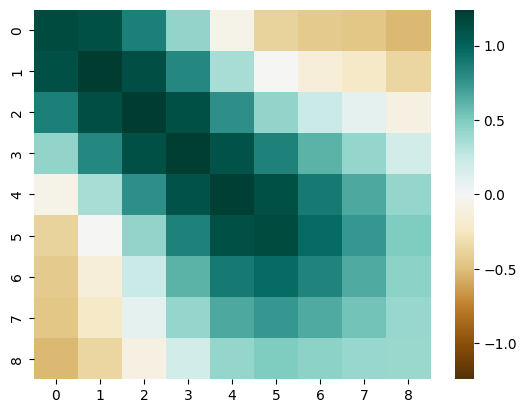

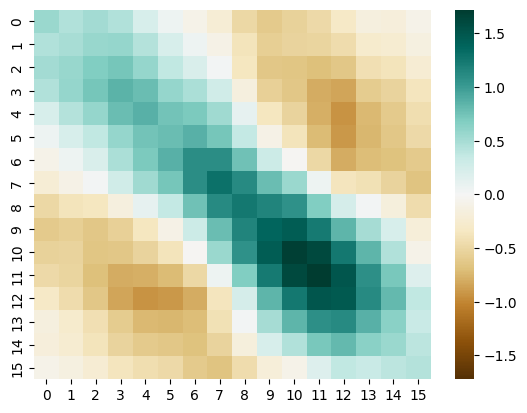

In [18]:
for k in range(3):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

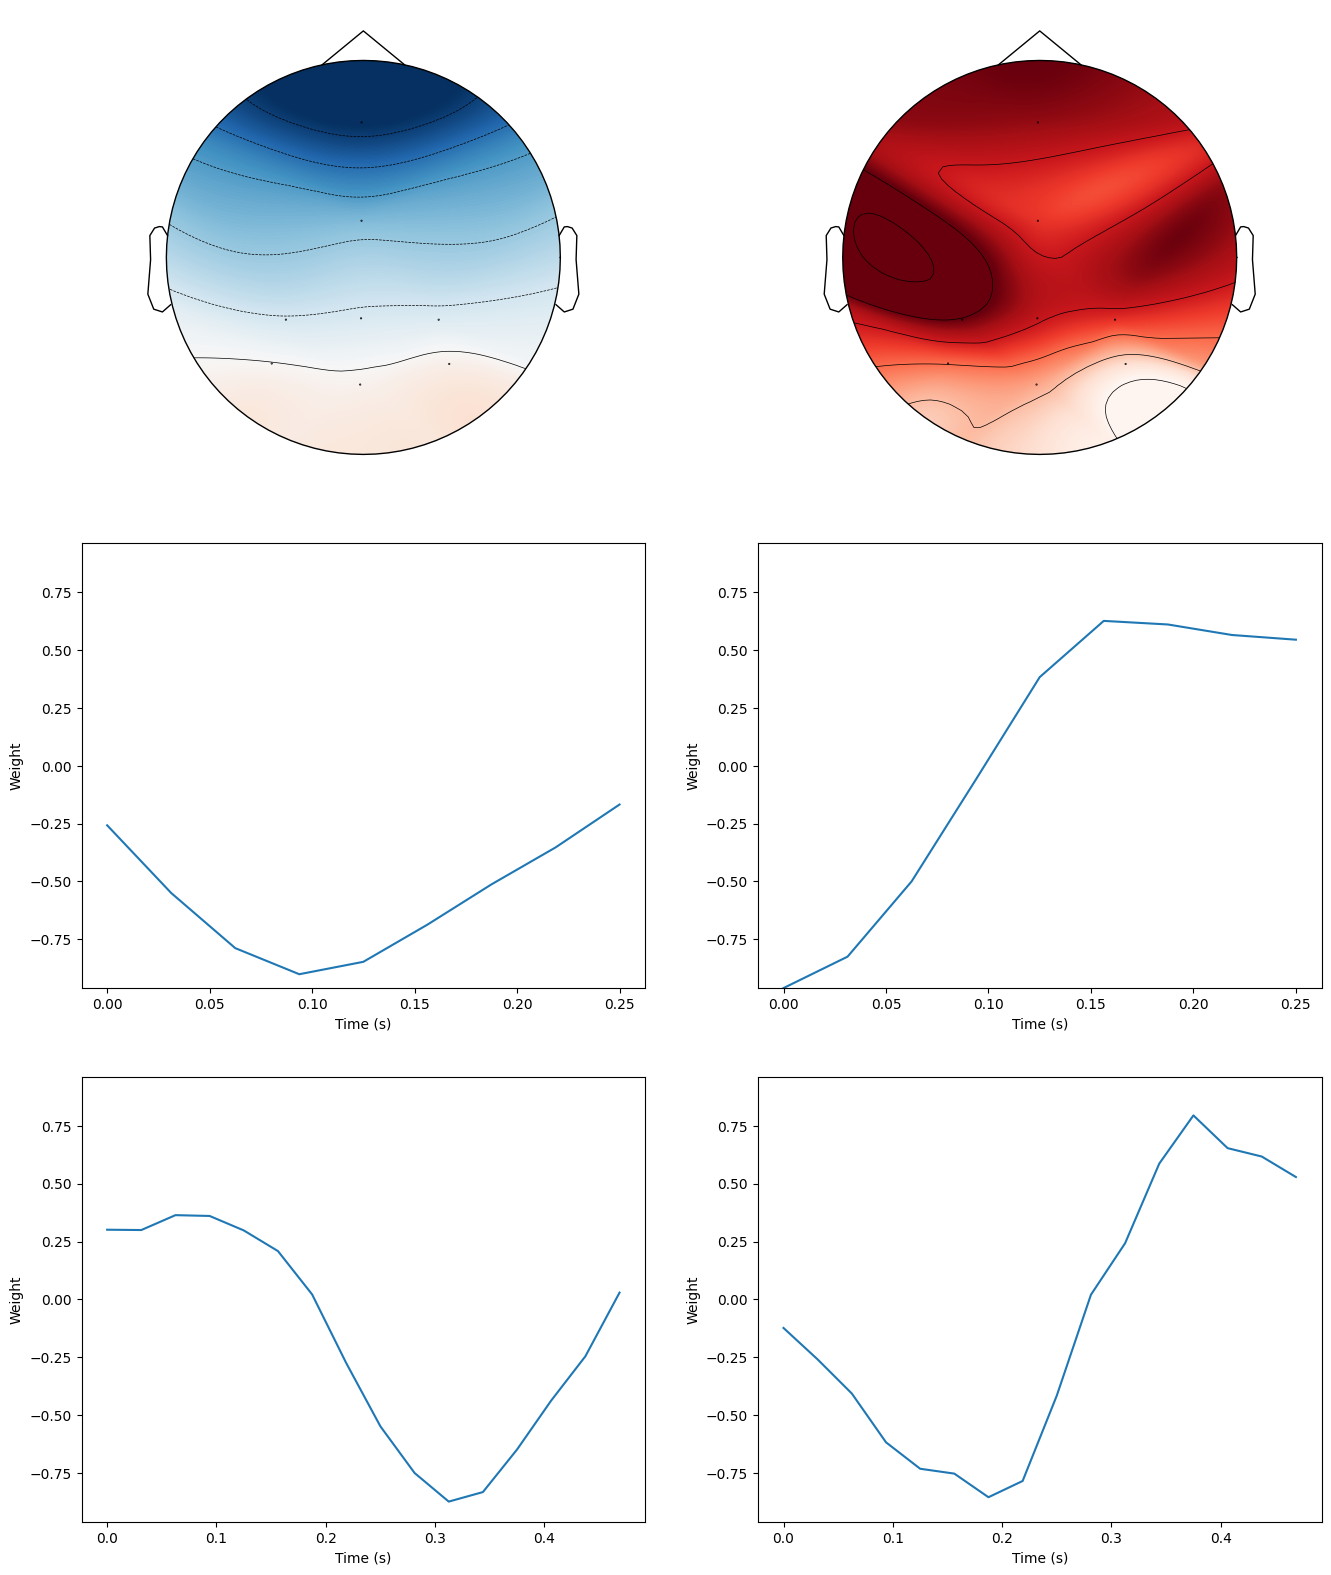

In [20]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank[0]):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank[1]):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
for i in range(hoda.rank[1]):
    w = aps[2][:,i]
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])

In [21]:
Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)
print(Xt_train.shape)
print(Xt_test.shape)

(2100, 8)
(2100, 8)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

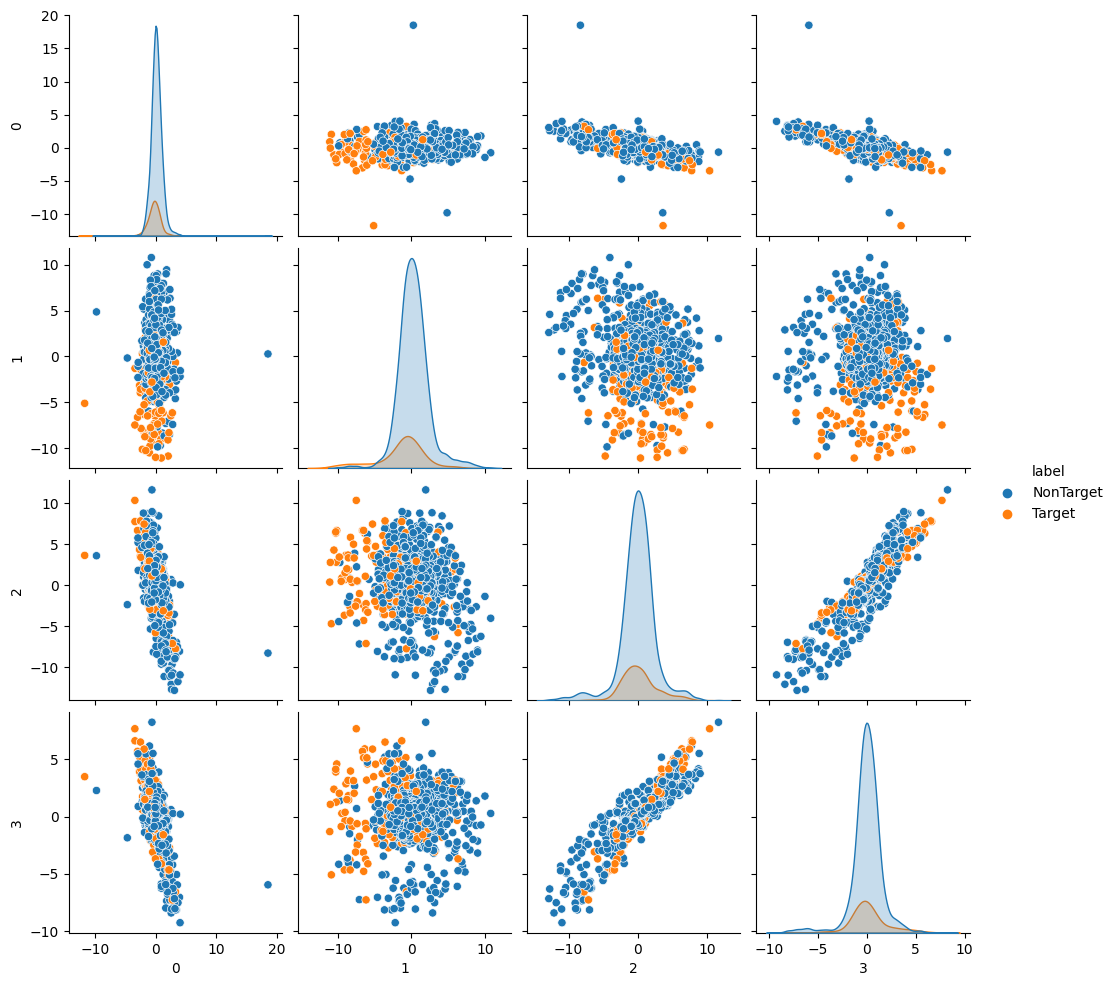

In [23]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [24]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.7234204081632654

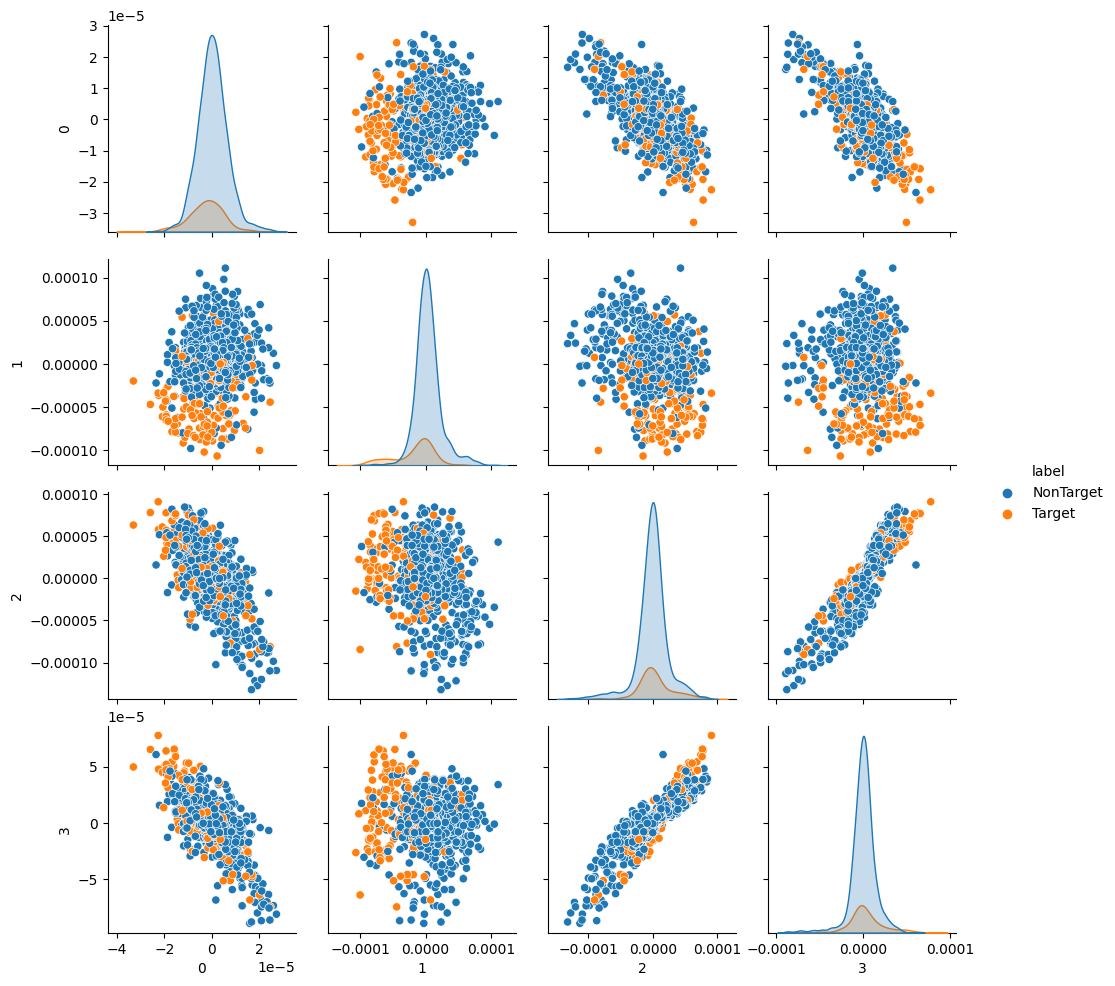

In [25]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [26]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.753273469387755